# Week 1 Group Projects

This notebook is based on the analysis.ipynb, and attempts the following:
- load in the RBC Data
- randomly draw a subset of training set subject to calculate correlation matrix
- (potentially) also run PCA
- Answer the following question:
    1. How correlated is surface area/volume/curviture/thickness/constrast?
    2. How correlated are parcels within the same network?

## Getting Started with RBC Data

To load in some of the RBC data, we'll use some tools already installed on the
HUB: `rbclib` and `pandas`.
The `rbclib` library allows us to access RBC data from the cloud; it is
demonstrated below.

The `pandas` library handles spreadsheet data (called `DataFrame`s in Python)
and can read tab-separated and comma-separated value files (`*.tsv` and
`*.csv` files).

In [25]:
# We will need the RBCPath type from the rbclib package to load data from the RBC.
from rbclib import RBCPath

# We'll also want to load some data directly from the filesystem.
from pathlib import Path

# We'll want to load/process some of the data using pandas and numpy.
import pandas as pd
import numpy as np

### Accessing the PNC Dataset

The RBC project contains many datasets; for this project, we will focus on
just one of these datasets: the
[Philadelphia Neurodevelopmental Cohort](
https://www.med.upenn.edu/bbl/philadelphianeurodevelopmentalcohort.html)
(PNC). The PNC contains a lot of data, including raw MRI data. However, due to
the time constraints for this project, we suggest that teams focus on the
already processed data provided by the RBC, which is described below.

The RBC's data is stored in a combination of GitHub repositories and Amazon S3
buckets. The RBC GitHub repositories all belong to the organization
[`ReproBrainChart`](https://github.com/ReproBrainChart), and each contains a
subset of the data for one of the RBC datasets; for the PNC dataset, all
repositories names start with `PNC_`:

* `PNC_FreeSurfer`: structural data processed by FreeSurfer.
* `PNC_BIDS`: raw MRI scan data in the
  [Brain Imaging Data Structure](https://bids.neuroimaging.io/index.html)
  format.
* `PNC_CPAC`: processed functional MRI data.

One typically accesses the RBC using the [`datalad`](https://www.datalad.org/)
tool (see the [RBC page on accessing the data](
https://reprobrainchart.github.io/docs/get_data) for more information).
However, we will access the data using the `RBCPath` type that was imported in
the code-cell above (`from rbclib import RBCPath`). This type inherits from a
type called `CloudPath` (from the library [`cloudpathlib`](
https://cloudpathlib.drivendata.org/stable/)); it represents the path of a
file in the RBC dataset and can be used to access data in thecloud as if it
were local.

For example, the following cell creates an `RBCPath` to a subject's FreeSurfer
data directory then lists and prints the contents.

In [3]:
# This path refers to the repo github.com:ReproBrainChart/PNC_FreeSurfer;
# Subject 1000393599's directory is used as an example.
subject_id = 1000393599
# To browse the repo, use this link:
# https://github.com/ReproBrainChart/PNC_FreeSurfer/tree/main
sub_path = RBCPath(f'rbc://PNC_FreeSurfer/freesurfer/sub-{subject_id}')

# This path refers to a directory:
assert sub_path.is_dir()

# Print each file in the directory:
for file in sub_path.iterdir():
    print(repr(file))

RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_brainmeasures.json')
RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_brainmeasures.tsv')
RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_freesurfer.tar.xz')
RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_fsLR_den-164k.tar.xz')
RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_fsaverage.tar.xz')
RBCPath('rbc://PNC_FreeSurfer//home/jovyan/shared/data/RBC/repos/PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_regionsurfacestats.tsv')


If we want to open and load one of these files, we can do so using the
`RBCPath.open` method. This method is like the `Path.open` method (from the
built-in Python library [`pathlib`](1)). For example, if we want to load this
subject's `regionsurfacestats.tsv` file, we can do so as follows.

[1]: https://docs.python.org/3/library/pathlib.html

In [4]:
# We can construct new paths by using the `/` operator. This is identical to
# how paths are constructed in the `pathlib` module.
stats_filepath = sub_path / f'sub-{subject_id}_regionsurfacestats.tsv'

# Use pandas to read in the TSV file then display it:

print(f"Loading {stats_filepath} ...")
with stats_filepath.open('r') as f:
    data = pd.read_csv(f, sep='\t')

data

Loading rbc://PNC_FreeSurfer/freesurfer/sub-1000393599/sub-1000393599_regionsurfacestats.tsv ...


,subject_id,session_id,atlas,hemisphere,StructName,NumVert,SurfArea,GrayVol,ThickAvg,ThickStd,...,StdDev_wgpct,Min_wgpct,Max_wgpct,Range_wgpct,SNR_wgpct,Mean_piallgi,StdDev_piallgi,Min_piallgi,Max_piallgi,Range_piallgi
0,sub-1000393599,NaN,aparc.DKTatlas,lh,caudalanteriorcingulate,1668,1121,3493,2.870,0.588,...,5.8371,-1.8413,42.8855,44.7269,4.4281,1.9877,0.0777,1.8054,2.1455,0.3402
1,sub-1000393599,NaN,aparc.DKTatlas,lh,caudalmiddlefrontal,3308,2236,7030,2.882,0.537,...,4.6666,7.1531,40.4774,33.3243,5.0341,3.3898,0.2448,2.7003,3.8032,1.1029
2,sub-1000393599,NaN,aparc.DKTatlas,lh,cuneus,4102,2619,5753,2.019,0.490,...,5.2623,-13.1617,33.8137,46.9754,3.0343,3.2453,0.3093,2.4099,3.5491,1.1392
3,sub-1000393599,NaN,aparc.DKTatlas,lh,entorhinal,737,549,2714,3.655,0.585,...,6.0438,2.5989,37.5099,34.9110,3.4560,2.6710,0.1285,2.4654,2.9647,0.4993
4,sub-1000393599,NaN,aparc.DKTatlas,lh,fusiform,4115,2822,8180,2.738,0.526,...,5.2854,-5.9378,39.6908,45.6286,3.9405,2.8272,0.1093,2.3304,3.1105,0.7800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13735,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_3,14937,9936,27688,2.611,0.492,...,5.0774,-10.8846,39.2314,50.1161,4.1769,3.1173,0.3747,2.4544,4.7044,2.2500
13736,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_4,13382,9146,29555,2.909,0.582,...,5.8317,-41.1954,52.2013,93.3967,3.8157,3.5262,0.9928,1.8828,5.1531,3.2703
13737,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_5,10558,7677,31072,3.196,0.792,...,7.1063,-22.2837,88.8118,111.0955,3.3020,2.5300,0.3971,2.0215,4.7753,2.7538
13738,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_6,20144,13602,41999,2.696,0.641,...,6.0781,-11.6287,43.5814,55.2101,3.6592,3.0563,0.5547,1.8599,4.9149,3.0550


In [5]:
sf10017 = data[data["atlas"]=="Schaefer2018_100Parcels_17Networks_order"]

In [6]:
# Assuming your dataframe is currently stored in a variable named 'df'
sf10017['Network'] = sf10017['StructName'].str.split('_').str[2].astype('category')

# Display the updated dataframe to verify
print(sf10017[['StructName', 'Network']].head(30))

                                     StructName       Network
3959  Background+FreeSurfer_Defined_Medial_Wall        Medial
3960              17Networks_LH_VisCent_ExStr_1       VisCent
3961              17Networks_LH_VisCent_ExStr_2       VisCent
3962            17Networks_LH_VisCent_Striate_1       VisCent
3963              17Networks_LH_VisCent_ExStr_3       VisCent
3964           17Networks_LH_VisPeri_ExStrInf_1       VisPeri
3965            17Networks_LH_VisPeri_StriCal_1       VisPeri
3966           17Networks_LH_VisPeri_ExStrSup_1       VisPeri
3967                    17Networks_LH_SomMotA_1       SomMotA
3968                    17Networks_LH_SomMotA_2       SomMotA
3969                17Networks_LH_SomMotB_Aud_1       SomMotB
3970                 17Networks_LH_SomMotB_S2_1       SomMotB
3971                 17Networks_LH_SomMotB_S2_2       SomMotB
3972               17Networks_LH_SomMotB_Cent_1       SomMotB
3973          17Networks_LH_DorsAttnA_TempOcc_1     DorsAttnA
3974    

/tmp/ipykernel_2273/2142176135.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sf10017['Network'] = sf10017['StructName'].str.split('_').str[2].astype('category')


In [7]:
sf10017['Network'].unique()

['Medial', 'VisCent', 'VisPeri', 'SomMotA', 'SomMotB', ..., 'ContC', 'DefaultA', 'DefaultB', 'DefaultC', 'TempPar']
Length: 18
Categories (18, object): ['ContA', 'ContB', 'ContC', 'DefaultA', ..., 'SomMotB', 'TempPar', 'VisCent', 'VisPeri']

In [8]:
sf10017.columns

Index(['subject_id', 'session_id', 'atlas', 'hemisphere', 'StructName',
       'NumVert', 'SurfArea', 'GrayVol', 'ThickAvg', 'ThickStd', 'MeanCurv',
       'GausCurv', 'FoldInd', 'CurvInd', 'Index', 'SegId', 'Mean_wgpct',
       'StdDev_wgpct', 'Min_wgpct', 'Max_wgpct', 'Range_wgpct', 'SNR_wgpct',
       'Mean_piallgi', 'StdDev_piallgi', 'Min_piallgi', 'Max_piallgi',
       'Range_piallgi', 'Network'],
      dtype='object')

In [9]:
numeric_features = ['NumVert', 'SurfArea', 'GrayVol', 'ThickAvg', 'ThickStd', 'MeanCurv',
       'GausCurv', 'FoldInd', 'CurvInd', 'Mean_wgpct',
       'StdDev_wgpct', 'Min_wgpct', 'Max_wgpct', 'Range_wgpct', 'SNR_wgpct',
       'Mean_piallgi', 'StdDev_piallgi', 'Min_piallgi', 'Max_piallgi',
       'Range_piallgi']
features_only = sf10017[numeric_features]
sub_corr = features_only.corr()
    
# # Append the raw matrix values to our list
# subject_matrices.append(sub_corr.values)

# # 3. Stack the matrices into a 3D numpy array and average across the subjects (axis 0)
# mean_corr_matrix = np.mean(np.stack(subject_matrices), axis=0)

# # 4. Turn it back into a readable dataframe for plotting
# mean_corr_df = pd.DataFrame(mean_corr_matrix, 
#                     index=numeric_features, 
#                     columns=numeric_features)

/srv/conda/envs/notebook/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


<Figure size 1200x1000 with 0 Axes>

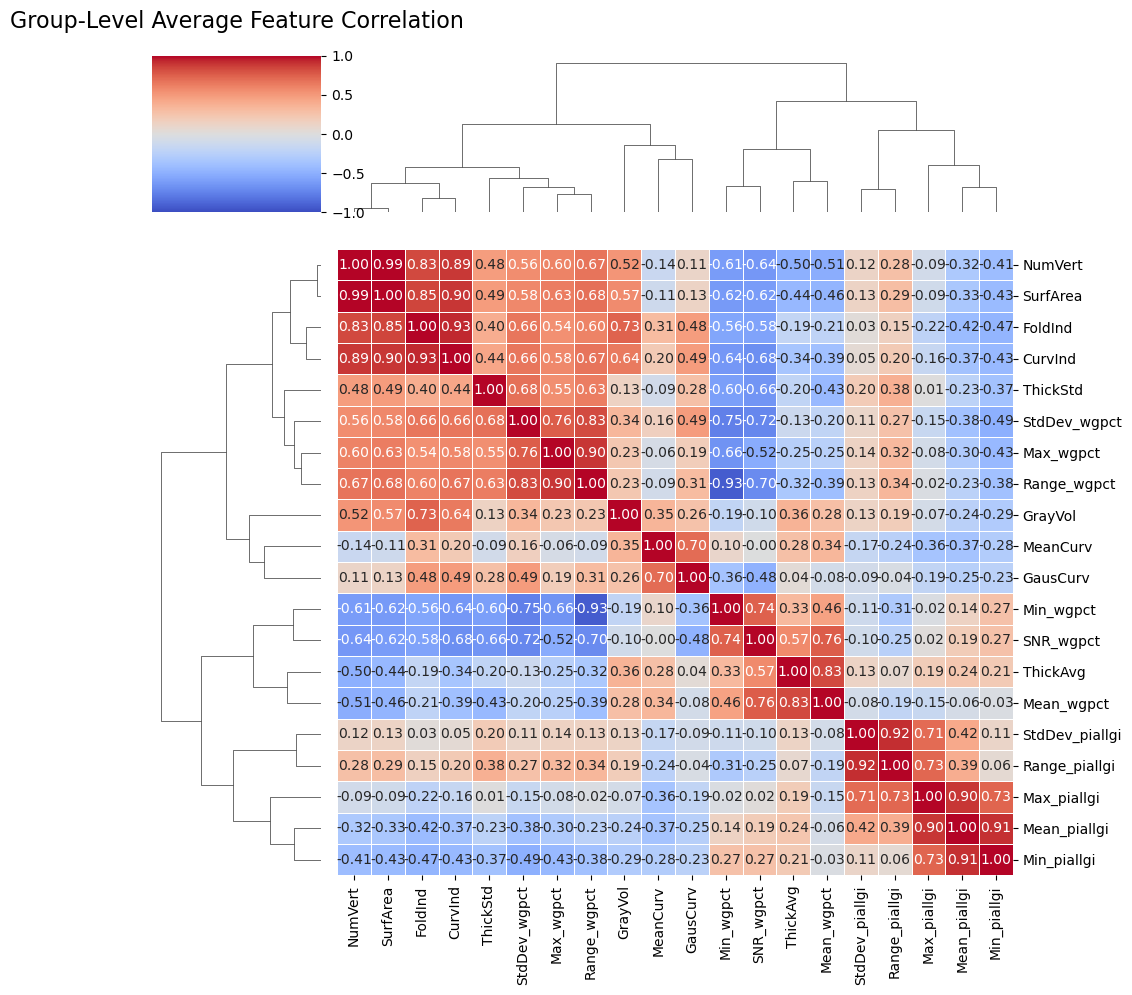

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set up the matplotlib figure size
plt.figure(figsize=(12, 10))

# 2. Generate the heatmap
sns.clustermap(
    sub_corr,           # The dataframe to visualize
    annot=True,             # Prints the correlation numbers inside the boxes
    fmt=".2f",              # Rounds those numbers to 2 decimal places
    cmap="coolwarm",        # Color map: Blue for negative, Red for positive
    vmin=-1, vmax=1,        # Locks the color scale exactly between -1 and 1
    square=True,            # Forces the grid cells to be perfectly square
    linewidths=0.5,         # Adds a subtle border between cells
    cbar_kws={"shrink": .8} # Shrinks the legend/colorbar slightly for aesthetics
)

# 3. Format the labels and title
plt.title("Group-Level Average Feature Correlation", fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right') # Angles the x-axis labels so they don't overlap
plt.yticks(rotation=0)

# 4. Adjust layout and display
plt.tight_layout()
plt.show()

In [32]:
numeric_features = ['NumVert', 'SurfArea', 'GrayVol', 'ThickAvg', 'ThickStd', 'MeanCurv',
       'GausCurv', 'FoldInd', 'CurvInd', 'Mean_wgpct',
       'StdDev_wgpct', 'Min_wgpct', 'Max_wgpct', 'Range_wgpct', 'SNR_wgpct',
       'Mean_piallgi', 'StdDev_piallgi', 'Min_piallgi', 'Max_piallgi',
       'Range_piallgi']

def load_schaefer_7net(participant_id):
    """Loads and returns the bilateral Brodmann Area 1 surface area for a PNC
    study participant.
    """
    # First, load the subject's FreeSurfer dataframe:
    data = load_fsdata(participant_id)
    # Next, find the relevant rows:
    row_mask = (data['atlas'] == 'Schaefer2018_100Parcels_17Networks_order')
    
    # Then extract and sum the surface areas:
    schaefer_7net = data[row_mask]
    #schaefer_7net['Network'] = schaefer_7net['StructName'].str.split('_').str[2].astype('category')

    #networks = schaefer_7net['Network'].unique()
    
    features_only = schaefer_7net[numeric_features]
    sub_corr = features_only.corr().to_numpy()

    return sub_corr 

### Getting the Participant Lists and Metadata

We have pre-sorted the participants in the PNC study into a training and a
test dataset. Basic metadata about each participant can be found in TSV files
in the `shared` directory in your home directory.

In [27]:
# Participant meta-data is generally located in the BIDS repository for each
# study:
rbcdata_path = Path('/home/jovyan/shared/data/RBC')
train_filepath = rbcdata_path / 'train_participants.tsv'
test_filepath = rbcdata_path / 'test_participants.tsv'

# Load the PNC participants TSV files...
with train_filepath.open('r') as f:
    train_data = pd.read_csv(f, sep='\t')
with test_filepath.open('r') as f:
    test_data = pd.read_csv(f, sep='\t')

# We can also concatenate the two datasets into a single dataset of all
# study participants:
all_data = pd.concat([train_data, test_data])

# Display the full dataframe:
all_data

,participant_id,study,study_site,session_id,wave,age,sex,race,ethnicity,bmi,handedness,participant_education,parent_1_education,parent_2_education,p_factor
0,1000393599,PNC,PNC1,PNC1,1,15.583333,Male,Black,not Hispanic or Latino,22.15,Right,9th Grade,Complete primary,Complete secondary,0.589907
1,1000881804,PNC,PNC1,PNC1,1,14.916667,Male,Black,not Hispanic or Latino,21.52,Right,7th Grade,Complete secondary,Complete secondary,-0.655377
2,1001970838,PNC,PNC1,PNC1,1,17.833333,Male,Other,Hispanic or Latino,23.98,Right,11th Grade,Complete tertiary,Complete tertiary,-0.659061
3,100527940,PNC,PNC1,PNC1,1,8.250000,Male,Black,not Hispanic or Latino,NaN,Ambidextrous,1st Grade,Complete secondary,Complete primary,-0.591516
4,1006151876,PNC,PNC1,PNC1,1,21.500000,Female,Other,not Hispanic or Latino,NaN,Right,12th Grade,Complete tertiary,Complete secondary,-0.377828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,4190603704,PNC,PNC1,PNC1,1,19.666667,Female,Black,not Hispanic or Latino,NaN,Right,11th Grade,Complete primary,Complete primary,NaN
317,1910420386,PNC,PNC1,PNC1,1,12.500000,Male,Black,not Hispanic or Latino,19.18,Right,6th Grade,Complete primary,Complete secondary,NaN
318,3993637691,PNC,PNC1,PNC1,1,17.000000,Male,Black,not Hispanic or Latino,21.28,Right,9th Grade,Complete secondary,Complete primary,NaN
319,2726043986,PNC,PNC1,PNC1,1,9.000000,Female,Black,not Hispanic or Latino,16.02,Right,2nd Grade,Complete primary,NaN,NaN


In [4]:
data.columns

Index(['subject_id', 'session_id', 'atlas', 'hemisphere', 'StructName',
       'NumVert', 'SurfArea', 'GrayVol', 'ThickAvg', 'ThickStd', 'MeanCurv',
       'GausCurv', 'FoldInd', 'CurvInd', 'Index', 'SegId', 'Mean_wgpct',
       'StdDev_wgpct', 'Min_wgpct', 'Max_wgpct', 'Range_wgpct', 'SNR_wgpct',
       'Mean_piallgi', 'StdDev_piallgi', 'Min_piallgi', 'Max_piallgi',
       'Range_piallgi'],
      dtype='object')

# Randomly sample a subset of the subjects in the training set

In [6]:
train_data

,participant_id,study,study_site,session_id,wave,age,sex,race,ethnicity,bmi,handedness,participant_education,parent_1_education,parent_2_education,p_factor
0,1000393599,PNC,PNC1,PNC1,1,15.583333,Male,Black,not Hispanic or Latino,22.15,Right,9th Grade,Complete primary,Complete secondary,0.589907
1,1000881804,PNC,PNC1,PNC1,1,14.916667,Male,Black,not Hispanic or Latino,21.52,Right,7th Grade,Complete secondary,Complete secondary,-0.655377
2,1001970838,PNC,PNC1,PNC1,1,17.833333,Male,Other,Hispanic or Latino,23.98,Right,11th Grade,Complete tertiary,Complete tertiary,-0.659061
3,100527940,PNC,PNC1,PNC1,1,8.250000,Male,Black,not Hispanic or Latino,NaN,Ambidextrous,1st Grade,Complete secondary,Complete primary,-0.591516
4,1006151876,PNC,PNC1,PNC1,1,21.500000,Female,Other,not Hispanic or Latino,NaN,Right,12th Grade,Complete tertiary,Complete secondary,-0.377828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1275,984757368,PNC,PNC1,PNC1,1,13.416667,Male,Black,not Hispanic or Latino,16.66,Right,5th Grade,Complete primary,NaN,0.607100
1276,986035435,PNC,PNC1,PNC1,1,9.916667,Female,White,not Hispanic or Latino,NaN,Right,3rd Grade,Complete primary,Complete primary,-0.872749
1277,987544292,PNC,PNC1,PNC1,1,18.416667,Female,White,not Hispanic or Latino,NaN,Right,11th Grade,Complete secondary,Complete primary,-1.136788
1278,993394555,PNC,PNC1,PNC1,1,19.500000,Female,White,not Hispanic or Latino,NaN,Right,Some College,Complete secondary,Complete secondary,-1.420477


## Project Goal: Predict the `p_factor`

The RBC datasets include a variable for each subject called the `p_factor`.
This factor is intended to capture overall psychopathology and is discussed at
length in RBC publications. The goal for this project is to train a
machine-learning tool to predict the `p_factor` of each participant in the
test dataset by using data from the participants in the training dataset.
Note that the `p_factor` column in the training dataset is provided, but the
`p_factor` column in the test dataset has been set to `NaN`.

Your specific task is to calculate predicted `p_factor` values, to insert
these values into the `'p_factor'` column of the provided `test_data`
dataframe, to save `test_data` to disk using the `test_data.to_csv` method
(example below), then finally to commit and push the file to your group's
GitHub repository.

We will look over the results of the group mini-projects together once
everyone has submitted their predictions.

**In this section, we demonstrate an example approach to predicting the
`p_factor` using one of the most straightforward supervised techniques in
machine learning: linear regression.** Suppose we suspected that the size of
Brodmann Area 1 was predictive of the `p_factor` in individual participants
and thus wanted to run a linear regression analysis to predict `p_factor` in
the test participants based on the relationship in the training participants.
Performing linear regression will require a few steps, which are likely to be
similar in your projects:

1. Collect the relevant data (the surface areas of BA1) into a dataframe.
2. Train the linear regression model using the training participants.
3. Use the trained model to predict the `p_factor` of the test subjects.
4. Export and commit our predictions.

### Step 1. Collect Data

The data we need to make the predictions are, for each participant, (1) the
surface area of BA1, and (2) the `p_factor`. We can collect these into a
dataframe using `pandas` and the `RBCPath` type (to load the data).

The surface area of BA1 can be found in the FreeSurfer TSV files examined
earlier in this notebook. We'll start by writing a function that loads the
appropriate TSV for for a given participant.

In order to speed up the loading of data during the project, we can specify
a `local_cache_dir` where any data downloaded using the function will be
automatically saved; the next time you load the same data, it will be loaded
from local storage instead of from S3 (local storage is much faster). The
function here uses the directory `cache` in your home directory by default,
but you can change this if you prefer a different directory. The directory
will be automatically created for you if it does not exist.

In [28]:
def load_fsdata(participant_id, local_cache_dir=(Path.home() / 'cache')):
    "Loads and returns the dataframe of a PNC participant's FreeSurfer data."

    # Check that the local_cache_dir exists and make it if it doesn't.
    if local_cache_dir is not None:
        local_cache_dir = Path(local_cache_dir)
        local_cache_dir.mkdir(exist_ok=True)
    
    # Make the RBCPath and find the appropriate file:
    pnc_freesurfer_path = RBCPath(
        'rbc://PNC_FreeSurfer/freesurfer',
        # We provide the local_cache_dir to the RBCPath object; all paths made
        # from this object will use the same cache directory.
        local_cache_dir=local_cache_dir)
    participant_path = pnc_freesurfer_path / f'sub-{participant_id}'
    tsv_path = participant_path / f'sub-{participant_id}_regionsurfacestats.tsv'

    # Use pandas to read in the TSV file:
    with tsv_path.open('r') as f:
        data = pd.read_csv(f, sep='\t')

    # Return the loaded data:
    return data

We can run this function to obtain a subject's FreeSurfer dataframe. This
dataframe contains information about various anatomical atlases that segment
the cortical surface into distinct regions. Notice that the `atlas` column of
the dataframe contains the name of distinct atlases while the `StructName`
column contains the name of the ROI described. The `SurfArea` column gives the
surface area of each ROI.

In [29]:
example_participant_id = 1000393599
data = load_fsdata(example_participant_id)

# Display the dataframe we loaded:
data

,subject_id,session_id,atlas,hemisphere,StructName,NumVert,SurfArea,GrayVol,ThickAvg,ThickStd,...,StdDev_wgpct,Min_wgpct,Max_wgpct,Range_wgpct,SNR_wgpct,Mean_piallgi,StdDev_piallgi,Min_piallgi,Max_piallgi,Range_piallgi
0,sub-1000393599,NaN,aparc.DKTatlas,lh,caudalanteriorcingulate,1668,1121,3493,2.870,0.588,...,5.8371,-1.8413,42.8855,44.7269,4.4281,1.9877,0.0777,1.8054,2.1455,0.3402
1,sub-1000393599,NaN,aparc.DKTatlas,lh,caudalmiddlefrontal,3308,2236,7030,2.882,0.537,...,4.6666,7.1531,40.4774,33.3243,5.0341,3.3898,0.2448,2.7003,3.8032,1.1029
2,sub-1000393599,NaN,aparc.DKTatlas,lh,cuneus,4102,2619,5753,2.019,0.490,...,5.2623,-13.1617,33.8137,46.9754,3.0343,3.2453,0.3093,2.4099,3.5491,1.1392
3,sub-1000393599,NaN,aparc.DKTatlas,lh,entorhinal,737,549,2714,3.655,0.585,...,6.0438,2.5989,37.5099,34.9110,3.4560,2.6710,0.1285,2.4654,2.9647,0.4993
4,sub-1000393599,NaN,aparc.DKTatlas,lh,fusiform,4115,2822,8180,2.738,0.526,...,5.2854,-5.9378,39.6908,45.6286,3.9405,2.8272,0.1093,2.3304,3.1105,0.7800
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13735,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_3,14937,9936,27688,2.611,0.492,...,5.0774,-10.8846,39.2314,50.1161,4.1769,3.1173,0.3747,2.4544,4.7044,2.2500
13736,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_4,13382,9146,29555,2.909,0.582,...,5.8317,-41.1954,52.2013,93.3967,3.8157,3.5262,0.9928,1.8828,5.1531,3.2703
13737,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_5,10558,7677,31072,3.196,0.792,...,7.1063,-22.2837,88.8118,111.0955,3.3020,2.5300,0.3971,2.0215,4.7753,2.7538
13738,sub-1000393599,NaN,Yeo2011_7Networks_N1000,rh,7Networks_6,20144,13602,41999,2.696,0.641,...,6.0781,-11.6287,43.5814,55.2101,3.6592,3.0563,0.5547,1.8599,4.9149,3.0550


To extract the surface area of BA1, we need to look for rows whose
`StructName` indicates that it represents BA1. In the RBC database, the name
`'Brodmann.1'` is used to represent Brodmann Area 1. We can select only the
rows of interest using this name.

In [8]:
row_mask = (data['StructName'] == 'Brodmann.1')
data[row_mask]

,subject_id,session_id,atlas,hemisphere,StructName,NumVert,SurfArea,GrayVol,ThickAvg,ThickStd,...,StdDev_wgpct,Min_wgpct,Max_wgpct,Range_wgpct,SNR_wgpct,Mean_piallgi,StdDev_piallgi,Min_piallgi,Max_piallgi,Range_piallgi
1876,sub-1000393599,NaN,PALS_B12_Brodmann,lh,Brodmann.1,2851,1753,4067,2.069,0.576,...,5.2783,-7.2181,32.3884,39.6064,3.0996,3.4915,0.6993,2.4164,5.3746,2.9581
1919,sub-1000393599,NaN,PALS_B12_Brodmann,rh,Brodmann.1,2379,1537,3766,2.008,0.586,...,4.8646,-6.7201,38.8376,45.5577,3.3062,3.2389,0.5011,2.4060,4.8009,2.3949


In [13]:
eyeball = data[row_mask]
eyeball.columns

Index(['subject_id', 'session_id', 'atlas', 'hemisphere', 'StructName',
       'NumVert', 'SurfArea', 'GrayVol', 'ThickAvg', 'ThickStd', 'MeanCurv',
       'GausCurv', 'FoldInd', 'CurvInd', 'Index', 'SegId', 'Mean_wgpct',
       'StdDev_wgpct', 'Min_wgpct', 'Max_wgpct', 'Range_wgpct', 'SNR_wgpct',
       'Mean_piallgi', 'StdDev_piallgi', 'Min_piallgi', 'Max_piallgi',
       'Range_piallgi'],
      dtype='object')

Given these rows, we can extract the BA1 surface areas and sum them (we will
perform the linear regression on the bilateral BA1 surface area by adding the
left and right hemisphere surface areas).

In [9]:
ba1_surfareas = data.loc[row_mask, 'SurfArea']
ba1_surfarea = sum(ba1_surfareas)

# Show the bilateral surface area for this participant (in square mm):
ba1_surfarea

3290

Based on the above workflow, we can now write a function that extracts the BA1
surface area for a participant.

In [8]:
def load_ba1_surfarea(participant_id):
    """Loads and returns the bilateral Brodmann Area 1 surface area for a PNC
    study participant.
    """
    # First, load the subject's FreeSurfer dataframe:
    data = load_fsdata(participant_id)
    # Next, find the relevant rows:
    row_mask = (data['StructName'] == 'Brodmann.1')
    # Then extract and sum the surface areas:
    ba1_surfareas = data.loc[row_mask, 'SurfArea']
    ba1_surfarea = sum(ba1_surfareas)
    # And return this value:
    return ba1_surfarea

Let's test this function:

In [33]:
a = load_schaefer_7net(example_participant_id)

In [35]:
a.shape

(20, 20)

Now that we have code written to extract data from a single subject, we can
gather the BA1 data for our training and test subjects into a single
dataframe. Doing so will require downloading all of the TSV files for all of
the subjects in the training dataset. This will take some time, but probably
less than an hour.

In [ ]:
# Some subjects have missing data, so we want to catch the HTTPErrors that
# arise from them and insert NaNs for these subjects.
from urllib.error import HTTPError

# First load in surface area data for each participant:
print("Loading surface areas...")     

# We will put the rows in this dictionary of lists as we build the dataframe:
all_vars = {
    'participant_id': [],
    'corr': [],
    'p_factor': []}

# We'll display a progress bar `prog` as we go also:
from ipywidgets import IntProgress
prog = IntProgress(min=0, max=len(all_data))
display(prog)

# Okay, loop through each row of the `all_data` dataframe, which contains both
# training and test subjects, load their BA1 data, and store it in the
# all_vars dictionary.
for (ii, row) in all_data.iterrows():
    # Extract the participant ID and p_factor (which will be NaN for test
    # participants).
    participant_id = row['participant_id']
    p_factor = row['p_factor']
    # Load the surface area for this participant:
    try:
        surf_area = load_schaefer_7net(participant_id)
    except (FileNotFoundError, HTTPError):
        # Some subjects are just missing the file, so we code them as NaN.
        sub_corr = np.nan
    # Append the participant ID and their surface area to our dataset:
    all_vars['participant_id'].append(participant_id)
    all_vars['corr'].append(sub_corr)
    all_vars['p_factor'].append(p_factor)
    # Increment the progress bar counter:
    prog.value += 1

# Convert train_vars into a dataframe.
all_vars = pd.DataFrame(all_vars)

# Extract the training and test subjects into separate dataframes; the test
# participants can be identified as those having NaN values for their
# p_factor column.
train_vars = all_vars[~np.isnan(all_vars['p_factor'])]
test_vars = all_vars[np.isnan(all_vars['p_factor'])]

# Display the finished dataframe.
all_vars

Loading surface areas...


IntProgress(value=0, max=1601)

In [11]:
import pandas as pd
import numpy as np
from urllib.error import HTTPError
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm

print("Loading surface areas...")

# 1. Create a helper function to handle a single subject
def fetch_subject_data(participant_id, p_factor):
    try:
        surf_area = load_ba1_surfarea(participant_id)
    except (FileNotFoundError, HTTPError):
        surf_area = np.nan
    
    # Return a tuple instead of appending to a global dict (thread-safe and faster)
    return (participant_id, surf_area, p_factor)

# 2. Extract data using itertuples() instead of iterrows()
# This creates a list of arguments to feed into our threads
tasks = [(row.participant_id, row.p_factor) for row in all_data.itertuples(index=False)]

results = []

# 3. Use ThreadPoolExecutor to download multiple subjects at once
# Note: max_workers=20 means 20 requests at a time. Reduce if the API blocks you.
with ThreadPoolExecutor(max_workers=20) as executor:
    # Submit all tasks to the pool
    futures = [executor.submit(fetch_subject_data, p_id, p_fact) for p_id, p_fact in tasks]
    
    # as_completed yields results as soon as they finish, tqdm handles the progress bar
    for future in tqdm(as_completed(futures), total=len(tasks), desc="Fetching Data"):
        results.append(future.result())

# 4. Convert the list of tuples directly into a DataFrame (very fast)
all_vars = pd.DataFrame(results, columns=['participant_id', 'ba1_surface_area', 'p_factor'])

# Extract the training and test subjects
train_vars = all_vars[~all_vars['p_factor'].isna()]
test_vars = all_vars[all_vars['p_factor'].isna()]

Loading surface areas...


Fetching Data:   0%|          | 0/1601 [00:00<?, ?it/s]

### Step 2. Train the Linear Regression

To train and perform the linear regression analysis, we will use the
[`LinearRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
type from scikit-learn.

In [14]:
# Import the LinearRegression type:
from sklearn.linear_model import LinearRegression

# LinearRegression requires a matrix whose columns are the variables and whose
# final column is the value being predicted (the p_factor for us). We can
# extract these columns straight from the dataframes we generated.
train_matrix = train_vars.loc[:, ['ba1_surface_area', 'p_factor']].values
# We need to exclude rows with NaNs for training:
train_okrows = np.all(~np.isnan(train_matrix), axis=1)
train_matrix = train_matrix[train_okrows]

# Train the regression using the training matrix:
lreg = LinearRegression()
lreg.fit(train_matrix[:, :1], train_matrix[:, 1])

# Display the trained regression parameters:
print("Linear Regression:")
print("  Intercept:", lreg.intercept_)
print("  Slope:", lreg.coef_)

Linear Regression:
  Intercept: 0.2999188013520533
  Slope: [-0.00026285]


### Step 3. Predict the `p_factor` of the Test Data

In [15]:
# We can apply the trained linear regression object `lreg` to the 1-column
# matrix of ba1_surface_area values in the test_vars dataframe.
test_matrix = test_vars.loc[:, ['ba1_surface_area']].values
test_okrows = np.all(~np.isnan(test_matrix), axis=1)

# Apply the model:
p_factor_predictions = np.zeros(len(test_matrix))
p_factor_predictions[test_okrows] = lreg.predict(test_matrix[test_okrows])

# Display the predictions:
p_factor_predictions

array([-0.33933552, -0.40977967, -0.44184752, -0.26205724, -0.46024711,
       -0.35352949, -0.36299214, -0.52490853, -0.47128687, -0.5709075 ,
       -0.37350619, -0.45262443, -0.27099419, -0.27467411, -0.36378069,
       -0.38165458, -0.45893286, -0.36036363, -0.45393868, -0.34459255,
       -0.42555074, -0.31331325, -0.55697639, -0.30463915, -0.29044518,
       -0.48232662, -0.45919571, -0.49993766, -0.37797466, -0.35852367,
       -0.53095411, -0.45157302, -0.45945856, -0.4883722 , -0.62952334,
       -0.37876322, -0.44500174, -0.42581359, -0.51255452, -0.38770016,
       -0.40241983, -0.3658835 , -0.42607645, -0.3961114 , -0.48495513,
       -0.39979132, -0.52779989, -0.42712785, -0.34800961, -0.36877487,
       -0.59456412, -0.38507165, -0.38822586, -0.33986122, -0.39584855,
       -0.45972141, -0.56170771, -0.69129339, -0.46156137, -0.48495513,
       -0.39532285, -0.4468417 , -0.48548084, -0.47023546, -0.46602984,
       -0.4888979 , -0.43185917, -0.52963985, -0.42870496, -0.48

### Step 4. Save and Commit the Results

To save and commit the results, we first need to save the predicted `p_factor`
data into the test dataframe (where there are currently NaNs). In the cell
above, we calculated the variable `test_okrows` that indicates which rows
of the `test_vars`, `test_matrix`, and `test_data` objects were predicted
(those that weren't predicted were excluded due to missing surface area data
in our case).

We can use this to insert the predicted `p_factor` data into `test_data`.

In [16]:
test_data.loc[:, 'p_factor'] = p_factor_predictions

# Display the resulting test data:
test_data

,participant_id,study,study_site,session_id,wave,age,sex,race,ethnicity,bmi,handedness,participant_education,parent_1_education,parent_2_education,p_factor
0,2285120424,PNC,PNC1,PNC1,1,16.166667,Female,Black,not Hispanic or Latino,22.67,Left,9th Grade,Complete secondary,Complete secondary,-0.339336
1,1854364375,PNC,PNC1,PNC1,1,16.833333,Female,White,not Hispanic or Latino,28.19,Right,10th Grade,Complete secondary,Complete primary,-0.409780
2,1448081953,PNC,PNC1,PNC1,1,19.583333,Female,White,not Hispanic or Latino,25.10,Right,Some College,Complete tertiary,Complete tertiary,-0.441848
3,1342685465,PNC,PNC1,PNC1,1,17.166667,Female,Black,not Hispanic or Latino,31.93,Right,10th Grade,Complete primary,Complete primary,-0.262057
4,3289562482,PNC,PNC1,PNC1,1,21.166667,Female,White,not Hispanic or Latino,NaN,Right,12th Grade,Complete tertiary,Complete secondary,-0.460247
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
316,4190603704,PNC,PNC1,PNC1,1,19.666667,Female,Black,not Hispanic or Latino,NaN,Right,11th Grade,Complete primary,Complete primary,-0.481275
317,1910420386,PNC,PNC1,PNC1,1,12.500000,Male,Black,not Hispanic or Latino,19.18,Right,6th Grade,Complete primary,Complete secondary,-0.506772
318,3993637691,PNC,PNC1,PNC1,1,17.000000,Male,Black,not Hispanic or Latino,21.28,Right,9th Grade,Complete secondary,Complete primary,-0.409780
319,2726043986,PNC,PNC1,PNC1,1,9.000000,Female,Black,not Hispanic or Latino,16.02,Right,2nd Grade,Complete primary,NaN,-0.310685


We now need to save the data to disk. We want to put this in the `results`
directory of the repository.

In [17]:
# The sep='\t' option here is necessary for tab-separated-value (as opposed to
# comma-separated-value) files. The `index=False` just indicates that pandas
# doesn't need to write out its own index column.

group_name = 'example'  # Change this to be your group name!

test_data.to_csv(f'results/{group_name}.tsv', sep='\t', index=False)

Once the tsv file has been saved, you can commit it to your GitHub repository
then push it and submit a pull request to the `results` branch of the original
repository!